In [1]:
import pyclass

In [2]:
from cosmoprimo.fiducial import DESI # tienes que tener el environment de cosmodesi


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cosmoprimo.fiducial import DESI # tienes que tener el environment de cosmodesi
from astropy.table import Table
from joblib import Parallel, delayed
from tqdm import tqdm
import time
from pixell import enmap
import copy
import matplotlib
from scipy import special, optimize, integrate, stats

# import classy module
from classy import Class
from scipy import integrate
from math import pi

####################################################################################################
# Pretty plots
####################################################################################################

plt.rcParams.update({
'lines.color':'black',
'font.family':'serif',
'font.weight':'normal',
'text.color':'black',
'text.usetex':True,
'axes.edgecolor':'black',
'axes.linewidth':2.5,
'axes.titlesize':'x-large',
'axes.labelsize':'x-large',
'axes.labelcolor':'black',
'xtick.labelsize':'x-large',
'xtick.minor.width':1.0,
'xtick.major.width':1.0,
'ytick.major.size':7,
'ytick.minor.size':4,
'ytick.major.pad':8,
'ytick.minor.pad':8,
'ytick.labelsize':'x-large',
'ytick.minor.width':1.0,
'ytick.major.width':1.0,
'legend.numpoints':1,
'legend.fontsize':'x-large',
'legend.shadow':False,
'legend.frameon':False})

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000

In [4]:
%config InlineBackend.figure_format='retina'
%matplotlib inline

from scipy.stats import chi2, binned_statistic as binnedstat
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set matplotlib parameters
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "mathtext.fontset": "stixsans",
    "font.size": 20,
    "axes.linewidth": 4,
    "ytick.major.size": 5,
    "xtick.major.size": 5,
    "xtick.labelsize": 20
})

## 1. Import pre and post reconstructed catalogs

These are split in North and South Galactic Caps. This is only for the LRGs, for the rest check the directories.

In [5]:
# Importing catalogs

main_directory = '//project/rrg-rbond-ac/jiaqu/DESI/catalogs/DA2/'
# pre_rec_directory = 'analysis/loa-v1/LSScats/v1.1/BAO/unblinded/desipipe/2pt/recon_sm15_IFFT_recsym/'
# post_rec_directory = "LSS/loa-v1/LSScats/v1.1/nonKP/"
!!!!i swap this to test
post_rec_directory = 'analysis/loa-v1/LSScats/v1.1/BAO/unblinded/desipipe/2pt/recon_sm15_IFFT_recsym/'
pre_rec_directory = "LSS/loa-v1/LSScats/v1.1/nonKP/"

# North Galactic Cap:
dat_pre_rec_NGC = Table.read(main_directory+pre_rec_directory+'LRG_NGC_clustering.dat.fits', format='fits')
pre_rec_NGC = dat_pre_rec_NGC.to_pandas()

dat_post_rec_NGC = Table.read(main_directory+post_rec_directory+'LRG_NGC_clustering.dat.fits', format='fits')
post_rec_NGC = dat_post_rec_NGC.to_pandas()

# South Galactic Cap:
dat_pre_rec_SGC = Table.read(main_directory+pre_rec_directory+'LRG_SGC_clustering.dat.fits', format='fits')
pre_rec_SGC = dat_pre_rec_SGC.to_pandas()

dat_post_rec_SGC = Table.read(main_directory+post_rec_directory+'LRG_SGC_clustering.dat.fits', format='fits')
post_rec_SGC = dat_post_rec_SGC.to_pandas()

# All (for visualization purposes)
pre_rec = pd.concat([pre_rec_NGC, pre_rec_SGC])

# DESI Legacy survey:
bins_directory = "/project/rrg-rbond-ac/jiaqu/DESI_LRG_legacy/dr9_lrg_pzbins.fits"
dat_bins = Table.read(bins_directory, format='fits')
bins = dat_bins.to_pandas()


In [6]:
dat_pre_rec_SGC_ran = Table.read(main_directory+pre_rec_directory+'LRG_SGC_0_clustering.ran.fits', format='fits')


In [32]:
dat_pre_rec_SGC_ran

TARGETID,RA,DEC,NTILE,PHOTSYS,FRAC_TLOBS_TILES,Z,WEIGHT,WEIGHT_SYS,WEIGHT_COMP,WEIGHT_ZFAIL,TARGETID_DATA,NX,WEIGHT_FKP
int64,float64,float64,int64,bytes1,float64,float64,float64,float64,float64,float64,int64,float64,float64
327857698848637143,21.699488025847675,-19.375747955151088,1,S,0.8247566063977747,0.8904776062286328,0.6119555117615456,1.0263125896453857,1.0,1.0075414180755615,39628390629641006,0.0002161094967594732,0.31634607952348137
327857698848637867,21.690238243910034,-19.396944798604157,1,S,0.8247566063977747,0.8480435936470956,0.5959330120002189,1.0067079067230225,1.0,1.0002686977386475,39627645855466895,0.0002711147286089404,0.2694584512310594
327857698848639410,21.700090176998838,-19.38118276360509,1,S,0.8247566063977747,0.7394480848142149,0.5758790169426024,0.9729616641998291,1.0,1.0001341104507446,39628423462653355,0.0002681599426678509,0.2716210766314104
327857698852831286,21.926750733015158,-19.43096718905237,1,S,0.8247566063977747,0.6090655581566332,0.5834156652350457,0.9858272075653076,1.0,1.0,39628005579953553,0.00029731187412514534,0.251691445719294
327857698852831318,21.833759038382357,-19.434743116116266,1,S,0.8247566063977747,0.8638095234806629,0.6175235076585605,1.032444715499878,1.0,1.0106700658798218,39627766882112049,0.0002523212059376037,0.2838319076874131
327857698852831382,21.798969252836027,-19.41231700896676,1,S,0.8247566063977747,0.7733150869865566,0.5927302679979335,1.001542091369629,1.0,1.000024437904358,39628088010607037,0.00028993099616030034,0.2564556318546425
327857698852831488,21.800228797972267,-19.39021323752439,1,S,0.8247566063977747,0.5511447912000867,1.137496091750822,0.961042582988739,2.0,1.0,39628403728452087,0.0002950631544047422,0.25312408632658767
327857698852831533,21.737486248692587,-19.403603169131284,1,S,0.8247566063977747,0.647393124849631,0.6038912903530357,1.0204259157180786,1.0,1.0,39628019215634971,0.00028204460749189583,0.2617495392920086
327857698852831582,21.87669927315589,-19.427417103488597,1,S,0.8247566063977747,0.4944344217367313,0.5909821965657942,0.9986127614974976,1.0,1.0,39627847387578925,0.000278560572888072,0.2641585182447585


In [9]:
bins

,TARGETID,RA,DEC,EBV,PIXEL_NOBS_G,PIXEL_NOBS_R,PIXEL_NOBS_Z,MASKBITS,PHOTSYS,Z_PHOT_MEDIAN,lrg_mask,pz_bin
0,39633377069893759,88.878360,59.235341,0.138075,3,3,2,0,b'N',0.739890,0,3
1,39633377069894013,88.908993,59.199573,0.135423,3,3,2,0,b'N',0.534148,0,1
2,39633377069894095,88.920681,59.252385,0.138563,3,3,2,0,b'N',0.480741,0,1
3,39633377069894255,88.940767,59.173325,0.135205,3,3,2,0,b'N',0.391874,0,-1
4,39633377069894264,88.941408,59.144725,0.135776,3,4,2,0,b'N',0.530794,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
12392204,39628565225934461,351.538608,34.099232,0.110874,1,1,2,2048,b'S',0.809066,8,3
12392205,39628565225934486,351.539825,33.992697,0.121760,1,1,3,0,b'S',0.598406,0,2
12392206,39628565225934490,351.540142,33.994398,0.121637,1,1,3,0,b'S',0.554581,0,2
12392207,39628565225934756,351.563254,34.120763,0.104835,1,1,3,0,b'S',0.857852,0,3


In [7]:
bins_directory = "/project/rrg-rbond-ac/jiaqu//dr9_extended_lrg_pzbins.fits"
dat_bins = Table.read(bins_directory, format='fits')
bins = dat_bins.to_pandas()

In [9]:
bins

,TARGETID,RA,DEC,EBV,PIXEL_NOBS_G,PIXEL_NOBS_R,PIXEL_NOBS_Z,MASKBITS,PHOTSYS,Z_PHOT_MEDIAN,lrg_mask,pz_bin,LOGM
0,39633377069893749,88.876620,59.176315,0.134617,3,3,2,0,b'N',1.100010,0,-1,-99.000000
1,39633377069893759,88.878360,59.235341,0.138075,3,3,2,0,b'N',0.739890,0,3,11.460811
2,39633377069893796,88.882672,59.163664,0.134543,3,3,2,0,b'N',0.630810,0,2,10.990633
3,39633377069893895,88.893773,59.129137,0.135118,3,3,2,0,b'N',0.941671,0,4,10.898431
4,39633377069894013,88.908993,59.199573,0.135423,3,3,2,0,b'N',0.534148,0,1,11.130031
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33735214,39628565225934486,351.539825,33.992697,0.121760,1,1,3,0,b'S',0.598406,0,2,11.116228
33735215,39628565225934490,351.540142,33.994398,0.121637,1,1,3,0,b'S',0.554581,0,2,10.936928
33735216,39628565225934756,351.563254,34.120763,0.104835,1,1,3,0,b'S',0.857852,0,3,10.955156
33735217,39628565225934786,351.565209,34.049718,0.116515,1,1,2,0,b'S',0.781698,0,3,11.333990


In [12]:
print("NGC: "+str(len(pre_rec_NGC)))
print("SGC: "+str(len(pre_rec_SGC)))
print("Total: "+str(len(pre_rec_NGC)+len(pre_rec_SGC)))


NGC: 2940585
SGC: 1527898
Total: 4468483


In [64]:
pre_rec_NGC

,TARGETID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,WEIGHT_IMLIN,WEIGHT_SYS,WEIGHT,WEIGHT_COMP,NX,WEIGHT_FKP,GC,DISP_LOS,VEL_LOS,VEL_LOS_RENORM
0,39627540901396844,0.420608,1,159.306842,-10.155758,b'S',0.874539,1.000000,1.000569,1.000569,0.626648,1.0,0.000281,0.262613,NGC,-1.397121,-61.080651,-72.916293
1,39627541627011285,0.866592,1,203.130799,-10.128731,b'S',0.826087,1.013171,0.951343,0.951343,0.603666,1.0,0.000248,0.287629,NGC,-2.518744,-128.068114,-123.041883
2,39627546827952170,0.580854,1,157.916650,-9.912096,b'S',0.828221,1.000000,0.996211,0.996211,2.495673,4.0,0.000282,0.261694,NGC,2.172086,100.771509,110.933977
3,39627546832142363,1.005906,1,157.944597,-9.885501,b'S',0.828221,1.001316,0.940173,0.940173,1.768793,3.0,0.000090,0.527136,NGC,-1.613759,-85.254305,-76.971984
4,39627546832142620,0.862610,1,157.961467,-9.894585,b'S',0.828221,1.003009,0.940173,0.940173,0.590594,1.0,0.000248,0.287629,NGC,2.276728,115.521003,111.189130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2940580,39637324534910135,0.670079,4,256.599275,32.343835,b'S',1.000000,1.000067,0.996192,0.996192,0.928673,1.0,0.000473,0.174588,NGC,5.680183,271.448000,286.038957
2940581,39637324534910283,0.600332,4,256.606611,32.135261,b'S',1.000000,1.000000,0.996192,0.996192,0.928611,1.0,0.000491,0.169301,NGC,2.391391,111.697292,121.782533
2940582,39637324534910312,0.568868,6,256.608068,32.246683,b'S',1.000000,1.000000,1.011148,1.011148,0.985648,1.0,0.000532,0.158331,NGC,4.232238,195.439730,216.433825
2940583,39637324534911137,0.696355,6,256.651973,32.354727,b'S',1.000000,1.000000,0.996192,0.996192,0.971070,1.0,0.000500,0.166666,NGC,4.048298,195.188132,203.090558


In [7]:
import healpy as hp

In [8]:
act_mask=hp.read_map('/scratch/jiaqu/actxdesi33/masks/sz_mask_hp.fits')

In [9]:
act_mask[act_mask!=0]=1

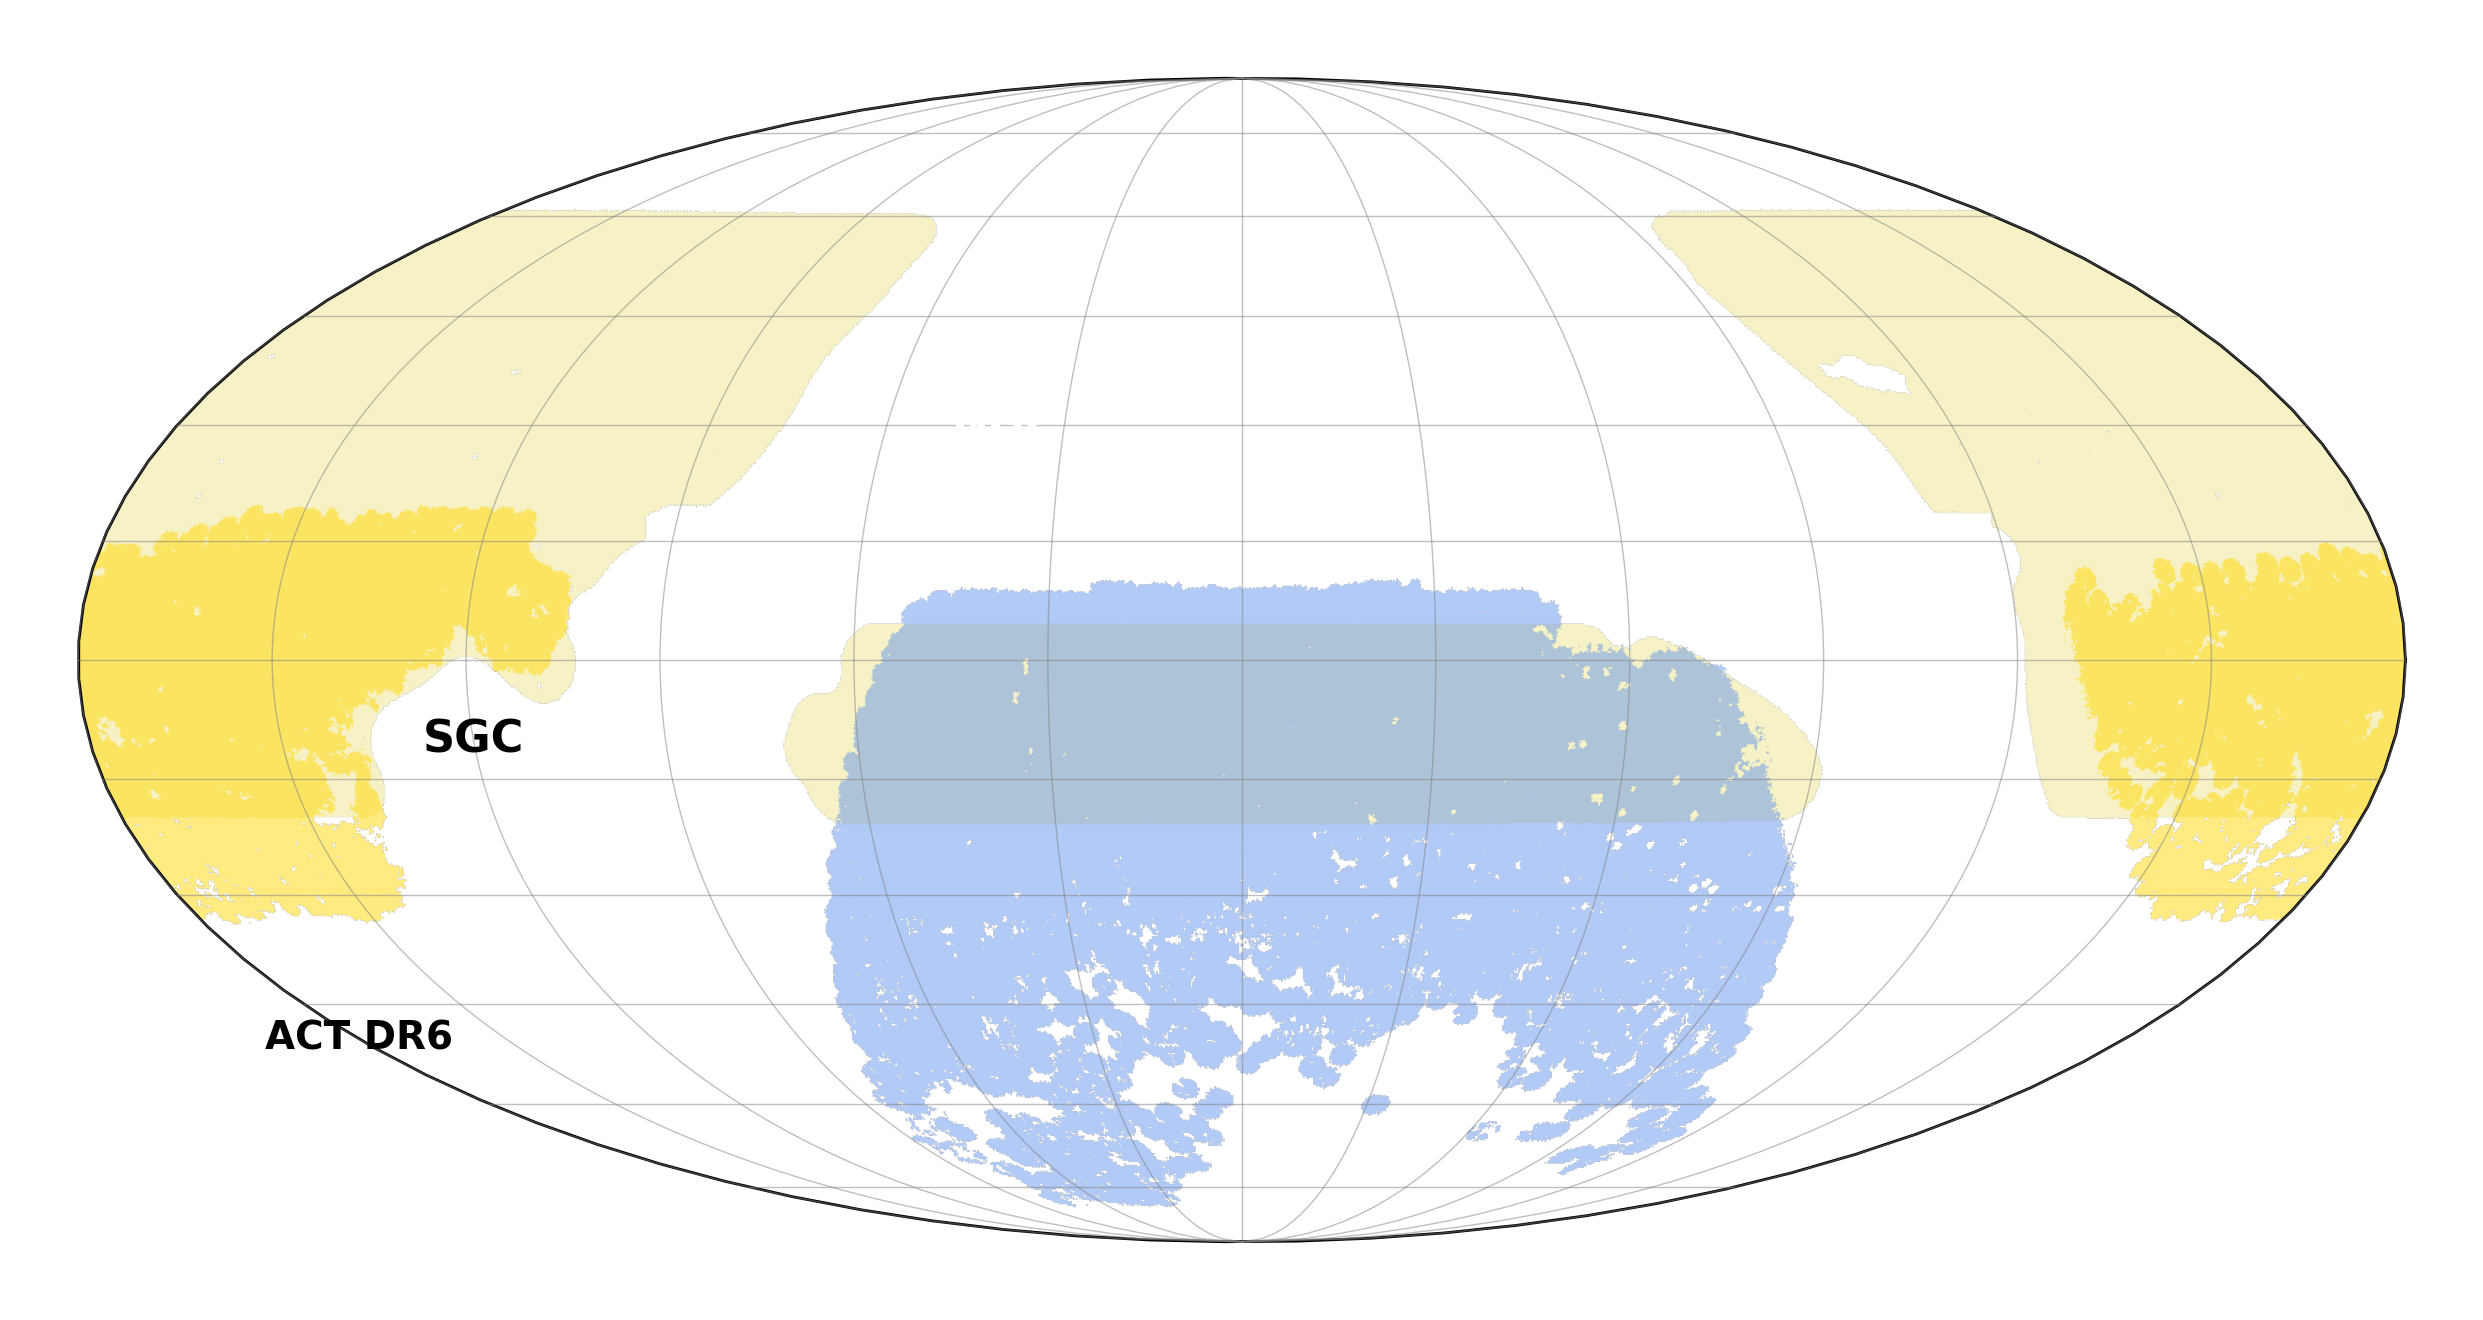

In [10]:
def create_full_footprint_map_custom_alpha(ra_ngc, dec_ngc, ra_sgc, dec_sgc, 
                                            act_mask=None, nside=256,
                                            alpha_act=0.7, alpha_ngc=0.9, alpha_sgc=0.9):
    """
    Show NGC, SGC, and ACT with individual alpha controls and true alpha blending
    for overlapping regions.
    
    Parameters:
    -----------
    alpha_act : float
        Transparency for ACT footprint (khaki)
    alpha_ngc : float
        Transparency for NGC (blue)
    alpha_sgc : float
        Transparency for SGC (yellow)
        
    Note: Overlapping regions show blended colors (e.g., NGC+SGC overlap appears greenish).
    """
    from matplotlib.colors import ListedColormap
    import matplotlib.colors as mcolors
    
    npix = hp.nside2npix(nside)
    
    # Create boolean masks for each region
    theta_ngc = np.radians(90.0 - dec_ngc)
    phi_ngc = np.radians(ra_ngc)
    pixels_ngc = hp.ang2pix(nside, theta_ngc, phi_ngc)
    ngc_mask = np.zeros(npix, dtype=bool)
    ngc_mask[pixels_ngc] = True
    
    theta_sgc = np.radians(90.0 - dec_sgc)
    phi_sgc = np.radians(ra_sgc)
    pixels_sgc = hp.ang2pix(nside, theta_sgc, phi_sgc)
    sgc_mask = np.zeros(npix, dtype=bool)
    sgc_mask[pixels_sgc] = True
    
    # ACT mask
    if act_mask is not None:
        if hp.npix2nside(len(act_mask)) != nside:
            act_mask_resized = hp.ud_grade(act_mask, nside)
        else:
            act_mask_resized = act_mask
        act_bool = act_mask_resized > 0
    else:
        act_bool = np.zeros(npix, dtype=bool)
    
    # Create combined footprint map with different values for each overlap case
    footprint_map = np.zeros(npix)
    
    # Assign values: 1=ACT, 2=ACT+NGC, 3=NGC, 4=SGC, 5=ACT+SGC, 6=NGC+SGC, 7=ACT+NGC+SGC
    footprint_map[act_bool & ~ngc_mask & ~sgc_mask] = 1  # ACT only
    footprint_map[act_bool & ngc_mask & ~sgc_mask] = 2   # ACT + NGC
    footprint_map[~act_bool & ngc_mask & ~sgc_mask] = 3  # NGC only
    footprint_map[~act_bool & ~ngc_mask & sgc_mask] = 4  # SGC only
    footprint_map[act_bool & ~ngc_mask & sgc_mask] = 5   # ACT + SGC
    footprint_map[~act_bool & ngc_mask & sgc_mask] = 6   # NGC + SGC
    footprint_map[act_bool & ngc_mask & sgc_mask] = 7    # ACT + NGC + SGC
    
    footprint_map[footprint_map == 0] = hp.UNSEEN
    
    # Alpha compositing helper function
    def blend_colors(colors_alphas):
        """Blend multiple RGBA colors using Porter-Duff over operator"""
        result = np.array([0.0, 0.0, 0.0, 0.0])
        for rgba in colors_alphas:
            c = np.array(rgba)
            result[:3] = c[:3] * c[3] + result[:3] * result[3] * (1 - c[3])
            result[3] = c[3] + result[3] * (1 - c[3])
        if result[3] > 0:
            result[:3] /= result[3]
        return result
    
    # Base colors with alpha
    act_rgba = mcolors.to_rgba('#F0E68C', alpha=alpha_act)  # Khaki
    ngc_rgba = mcolors.to_rgba('#6495ED', alpha=alpha_ngc)  # Blue
    sgc_rgba = mcolors.to_rgba('#FFD700', alpha=alpha_sgc)  # Yellow/Gold
    
    # Compute blended colors for each overlap case
    color_map = {
        1: act_rgba,                                    # ACT only
        2: blend_colors([act_rgba, ngc_rgba]),          # ACT + NGC
        3: ngc_rgba,                                    # NGC only
        4: sgc_rgba,                                    # SGC only
        5: blend_colors([act_rgba, sgc_rgba]),          # ACT + SGC
        6: blend_colors([ngc_rgba, sgc_rgba]),          # NGC + SGC
        7: blend_colors([act_rgba, ngc_rgba, sgc_rgba]) # All three
    }
    
    color_list = [color_map[i] for i in range(1, 8)]
    cmap = ListedColormap(color_list)
    
    fig = plt.figure(figsize=(14, 7))
    hp.mollview(footprint_map, title='', cmap=cmap, hold=True, cbar=False, 
                fig=fig, min=0.5, max=7.5)
    
    hp.graticule(dpar=15, dmer=30, coord='C')
    
    hp.projtext(140, 30, 'NGC', lonlat=True, fontsize=16, color='white', weight='bold')
    hp.projtext(60, -10, 'SGC', lonlat=True, fontsize=16, color='black', weight='bold')
    hp.projtext(0, -50, 'ACT DR6', lonlat=True, fontsize=14, color='black', weight='bold')
    
    plt.tight_layout()
    return fig

# Usage:
act_mask = hp.read_map('/scratch/jiaqu/actxdesi33/masks/sz_mask_hp.fits')
fig = create_full_footprint_map_custom_alpha(
    pre_rec_NGC['RA'], pre_rec_NGC['DEC'],
    pre_rec_SGC['RA'], pre_rec_SGC['DEC'],
    act_mask=act_mask,
    nside=256,
    alpha_act=0.5,
    alpha_ngc=0.5,
    alpha_sgc=0.5
)
plt.savefig('footprint_map_custom_alpha.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. BAO displacements and velocities

In [6]:
import pyclass

In [14]:
# Let's now obtain the displacements and velocities
cosmo = DESI()

# From Y1:
z_eff =  0.780
f_eff = cosmo.growth_rate(0.780) # No units

pre_rec_NGC["GC"] = "NGC"
pre_rec_SGC["GC"] = "SGC"

######################################################################

# Displacements along the LOS:
chi_pre_NGC = cosmo.comoving_radial_distance(pre_rec_NGC['Z']) # Mpc/h
chi_post_NGC = cosmo.comoving_radial_distance(post_rec_NGC['Z']) # Mpc/h

chi_pre_SGC = cosmo.comoving_radial_distance(pre_rec_SGC['Z']) # Mpc/h
chi_post_SGC = cosmo.comoving_radial_distance(post_rec_SGC['Z']) # Mpc/h

#why is the negative sign make sense here
disp_NGC_LOS = - (chi_post_NGC - chi_pre_NGC) / cosmo.h # Mpc
disp_SGC_LOS = - (chi_post_SGC - chi_pre_SGC) / cosmo.h # Mpc

disp_NGC_LOS /= (1 + f_eff) # Mpc, RSD correction
disp_SGC_LOS /= (1 + f_eff) # Mpc, RSD correction

pre_rec_NGC["DISP_LOS"] = disp_NGC_LOS # Mpc
pre_rec_SGC["DISP_LOS"] = disp_SGC_LOS # Mpc

######################################################################

# Velocities along the LOS: 
f_NGC = cosmo.growth_rate(post_rec_NGC['Z']) # No units
H_z_NGC = cosmo.hubble_function(post_rec_NGC['Z']) # km / (s Mpc)
a_NGC = 1/(1+post_rec_NGC['Z']) # No units

f_SGC = cosmo.growth_rate(post_rec_SGC['Z']) # No units
H_z_SGC = cosmo.hubble_function(post_rec_SGC['Z']) # km / (s Mpc)
a_SGC = 1/(1+post_rec_SGC['Z']) # No units

vel_NGC_LOS = a_NGC * H_z_NGC * f_NGC * disp_NGC_LOS # km/s
pre_rec_NGC["VEL_LOS"] = vel_NGC_LOS

vel_SGC_LOS = a_SGC * H_z_SGC * f_SGC * disp_SGC_LOS # km/s
pre_rec_SGC["VEL_LOS"] = vel_SGC_LOS

# ######################################################################

renorm_NGC = cosmo.growth_factor(pre_rec_NGC["Z"])/cosmo.growth_factor(z_eff)
renorm_SGC = cosmo.growth_factor(pre_rec_SGC["Z"])/cosmo.growth_factor(z_eff)

pre_rec_NGC["VEL_LOS_RENORM"] = vel_NGC_LOS*renorm_NGC
pre_rec_SGC["VEL_LOS_RENORM"] = vel_SGC_LOS*renorm_SGC


In [8]:
# Velocities along the LOS: 
pf_NGC = cosmo.growth_rate(pre_rec_NGC['Z']) # No units
pH_z_NGC = cosmo.hubble_function(pre_rec_NGC['Z']) # km / (s Mpc)
pa_NGC = 1/(1+pre_rec_NGC['Z']) # No units
pvel_NGC_LOS = -pa_NGC * pH_z_NGC * pf_NGC * disp_NGC_LOS # km/s


In [12]:
vel_NGC_LOS[0]

-61.08065111340768

In [13]:
pvel_NGC_LOS[0]

61.06287478508551

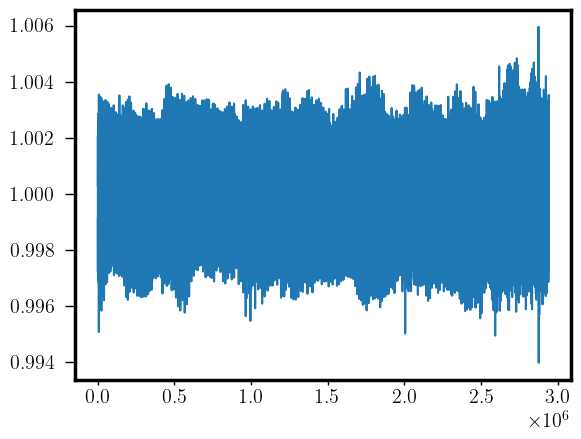

In [57]:
plt.plot(-vel_NGC_LOS/pvel_NGC_LOS)

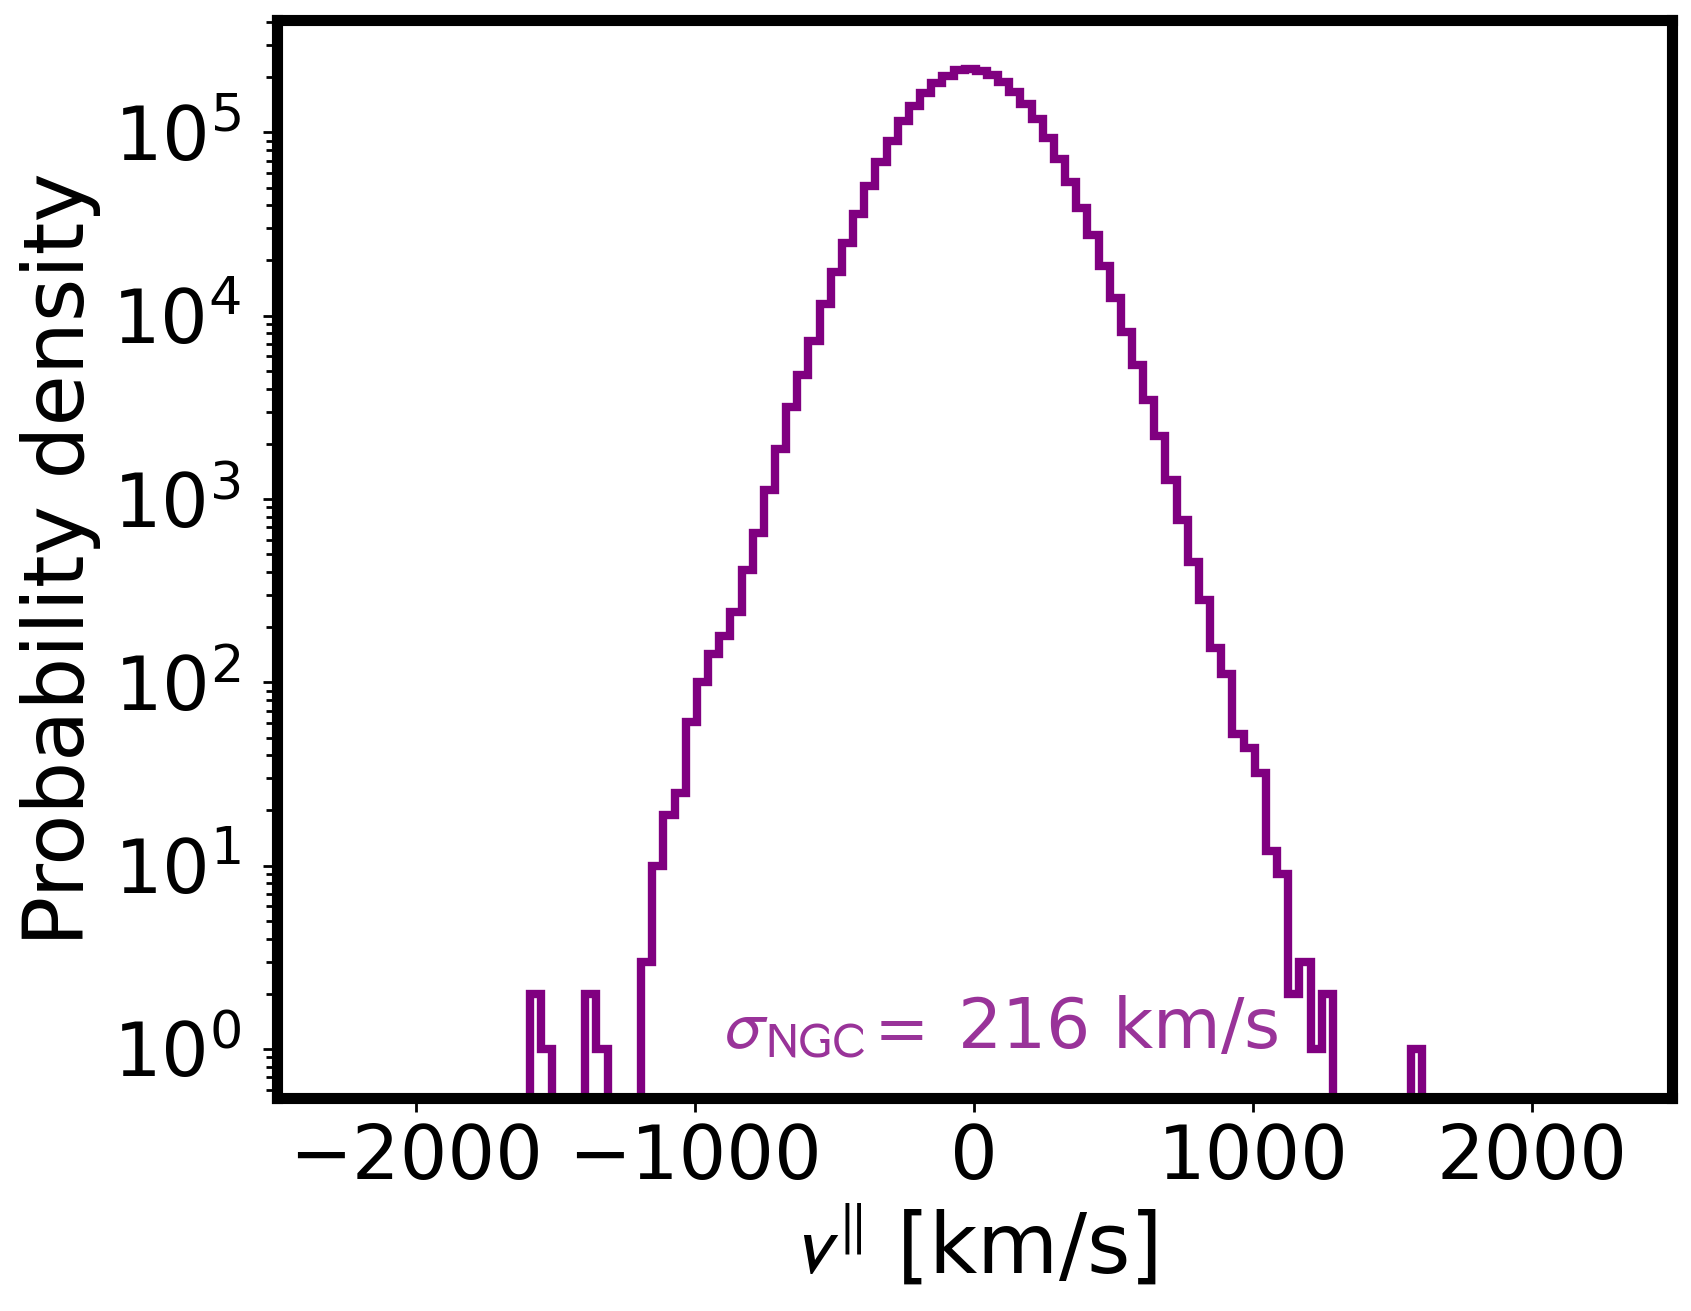

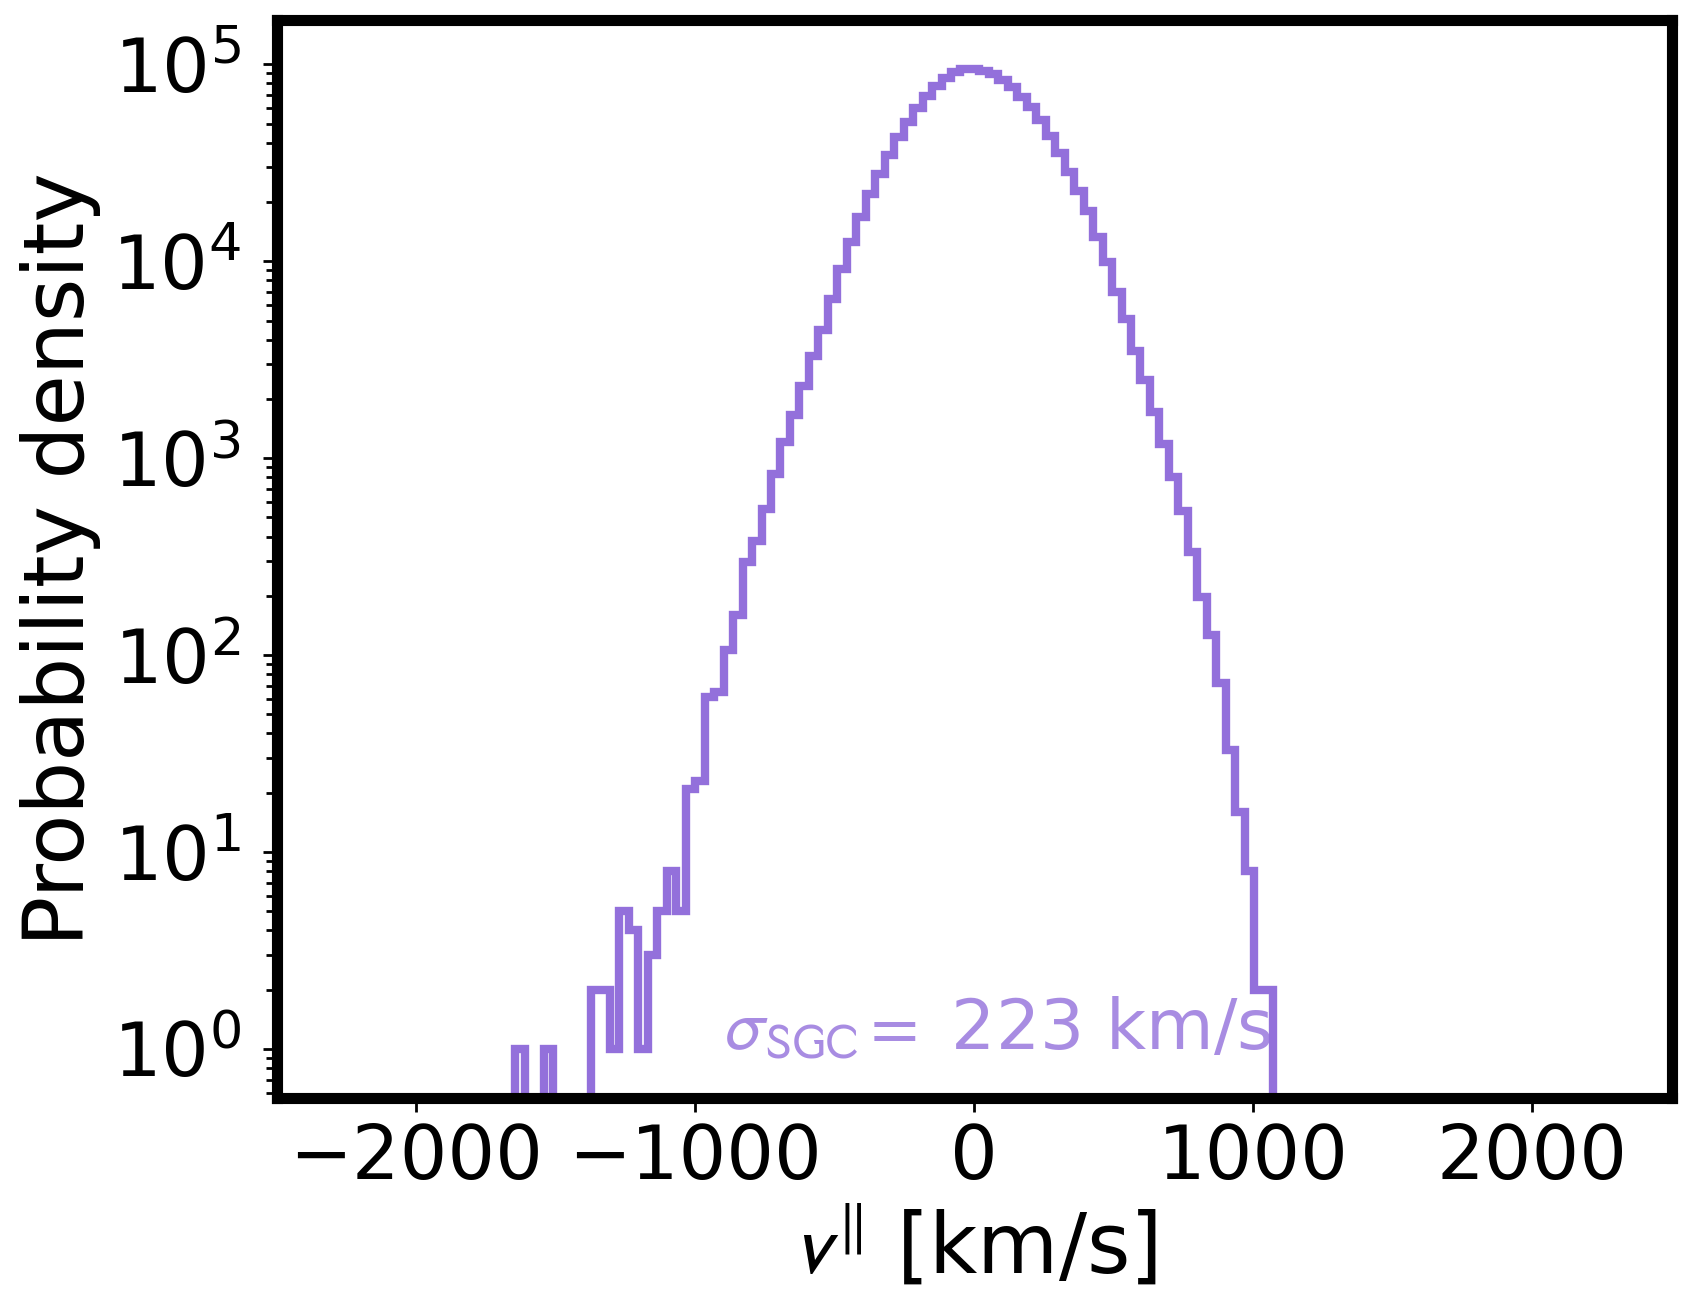

In [11]:
####################################################################################
# Plot of veclocity distribution NGC 
####################################################################################

num_bins = 80


mean_NGC_LOS = np.mean(-vel_NGC_LOS)
mean_SGC_LOS = np.mean(-vel_SGC_LOS)
sigma_NGC_LOS = np.std(-vel_NGC_LOS)
sigma_SGC_LOS = np.std(-vel_SGC_LOS)

fig, ax = plt.subplots(figsize=(9, 7))

counts_1, bins_1 =  np.histogram(-vel_NGC_LOS, density=False, bins=num_bins)

# y_NGC = ((1 / (np.sqrt(2 * np.pi) * sigma_NGC_LOS)) * np.exp(-0.5 * (1 / sigma_NGC_LOS * (bins_1 - mean_NGC_LOS))**2))
# ax.plot(bins_1, y_NGC, '--', linewidth=2, color='purple', alpha = 0.8)
ax.stairs(counts_1, bins_1, color='purple', linewidth=3, label=r"NGC")


plt.xlabel(r'$v^{\|}$ [km/s]', fontsize=30)
ax.set_ylabel('Probability density', fontsize=30)
plt.xticks(fontsize=27)
plt.yticks(fontsize=27)
ax.set_xlim(-2500, 2500)
# ax.set_ylim(10**(-9), 10**(-2))

ax.set_yscale('log')

plt.text(-900, 0.1*10**1, r"$\sigma_{\rm NGC} =$ "+str(int(sigma_NGC_LOS))+" km/s", color='purple', fontsize=25, alpha = 0.8)
          

# plt.savefig("distribution_vel_log_NGC.png", bbox_inches = "tight")

plt.show()

####################################################################################
# Plot of veclocity distribution SGC 
####################################################################################


fig, ax = plt.subplots(figsize=(9, 7))

counts_2, bins_2 =  np.histogram(-vel_SGC_LOS, density=False, bins=num_bins)

# y_SGC = ((1 / (np.sqrt(2 * np.pi) * sigma_SGC_LOS)) * np.exp(-0.5 * (1 / sigma_SGC_LOS * (bins_2 - mean_SGC_LOS))**2))
# ax.plot(bins_2, y_SGC, '--', linewidth=2, color='mediumpurple', alpha = 0.8)
ax.stairs(counts_2, bins_2, color='mediumpurple', linewidth=3, label=r"SGC")

plt.xlabel(r'$v^{\|}$ [km/s]', fontsize=30)
ax.set_ylabel('Probability density', fontsize=30)
plt.xticks(fontsize=27)
plt.yticks(fontsize=27)
ax.set_xlim(-2500, 2500)
ax.set_yscale('log')
# ax.set_ylim(10**(-9), 10**(-2))

plt.text(-900, 0.1*10**1, r"$\sigma_{\rm SGC} =$ "+str(int(sigma_SGC_LOS))+" km/s", color='mediumpurple', fontsize=25, alpha = 0.8)
    
# plt.savefig("distribution_vel_log_SGC.png", bbox_inches = "tight")
plt.show()


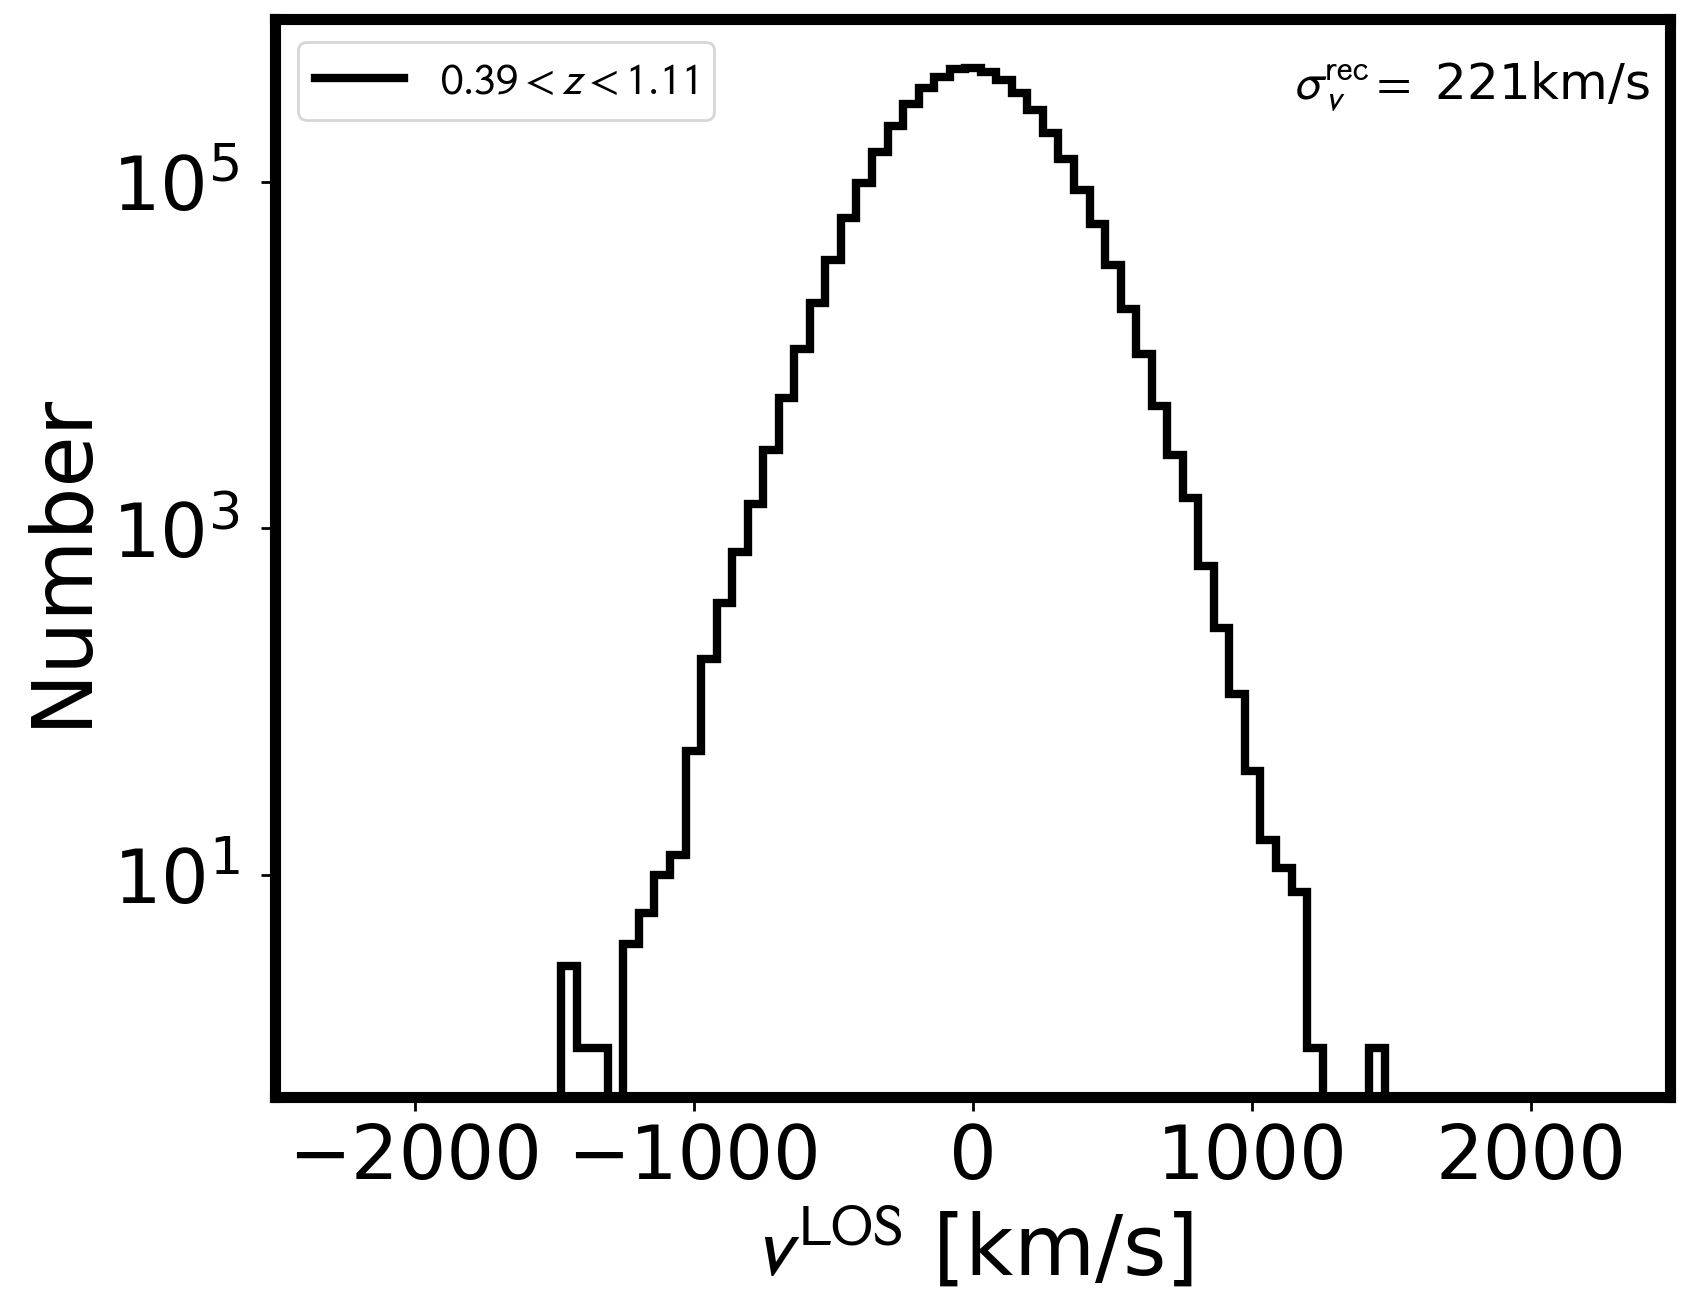

In [100]:
# num_bins = 80
num_bins = np.linspace(-2200, 2200, 80)

fig, ax = plt.subplots(figsize=(9, 7))

vel_LOS = -np.append(vel_NGC_LOS*renorm_NGC, vel_SGC_LOS*renorm_SGC)

mean_LOS = np.mean(vel_LOS)
sigma_LOS = np.std(vel_LOS)

counts_3, bins_3 = np.histogram(vel_LOS, density=False, bins=num_bins)

ax.stairs(counts_3, bins_3, color='k', linewidth=3, label=r"$0.39<z<1.11$")

plt.xlabel(r'$v^{\rm LOS}$ [km/s]', fontsize=30)
ax.set_ylabel('Number', fontsize=30)
plt.xticks(fontsize=27)
plt.yticks(fontsize=27)
ax.set_xlim(-2500, 2500)

# Adjusted text position
plt.text(1150, 30*10**4, r"$\sigma^{\rm rec}_{v} =$ "+str(int(sigma_LOS))+"km/s", color='k', fontsize=18)

ax.set_yscale('log')

# Adjust legend position inside the plot
plt.legend(loc='upper left', frameon=True, fontsize=16)

# Save figure
plt.savefig("figures/distribution_vel_log.pdf", bbox_inches="tight")

plt.show()


## 3. Merge catalogs and overlap with ACT DR6 map

In [15]:
# Merge the NGC and SGC samples
pre_rec = pd.concat([pre_rec_NGC, pre_rec_SGC])

# We sort them by redshift
pre_rec_sort = pd.DataFrame(pre_rec).sort_values("Z")


In [16]:
#also construct the non merged catalogues
pre_rec_NGC_sort = pd.DataFrame(pre_rec_NGC).sort_values("Z")
pre_rec_SGC_sort = pd.DataFrame(pre_rec_SGC).sort_values("Z")


/tmp/ipykernel_242308/3671983281.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  my_cmap = copy.copy(matplotlib.cm.get_cmap('viridis'))


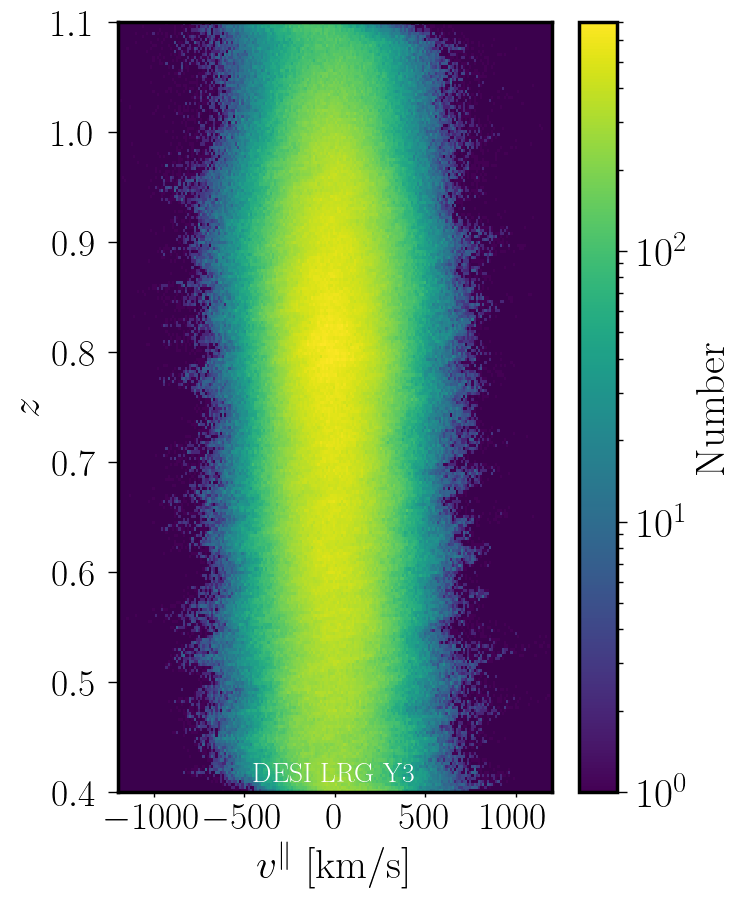

In [31]:
my_cmap = copy.copy(matplotlib.cm.get_cmap('viridis')) 
my_cmap.set_bad((0.23, 0.005, 0.3))
        
plt.figure(figsize=(7, 10))

h_desi = plt.hist2d(-pre_rec_sort["VEL_LOS_RENORM"], pre_rec_sort["Z"], bins=250, range=[[-1500, 1500], [0.4, 1.1]], rasterized=True, cmap=my_cmap, norm=matplotlib.colors.LogNorm())

cbar = plt.colorbar(h_desi[3])
cbar.set_label(label=r"Number", size=30)
plt.xticks(fontsize=27)
plt.yticks(fontsize=27)
tick_font_size = 30
cbar.ax.tick_params(labelsize=tick_font_size)
plt.clim(1, 700)
plt.xlim(-1200, 1200)
# plt.ylim(0.4, 1.1)

plt.xlabel(r'$v^{\|}$ [km/s]', fontsize=30)
plt.ylabel(r'$z$', fontsize=30)

plt.text(-450, 0.41, "DESI LRG Y3", color='white', fontsize=20)

plt.show()
    

In [13]:
# Select the ones overlapping with ACT

def sky2map(ra, dec, cmbMap):
    '''Gives the map value at coordinates (ra, dec).
    ra, dec in degrees.
    Uses nearest neighbor, no interpolation.
    Will return 0 if the coordinates requested are outside the map
    '''
    # interpolate the map to the given sky coordinates
    sourcecoord = np.array([dec, ra]) * (np.pi / 180)   # convert from degrees to radians
    # use nearest neighbor interpolation
    return cmbMap.at(sourcecoord, order=0)

cmbMap = enmap.read_fits("/project/rrg-rbond-ac/msyriac/ilc_dr6v3/20230606/hilc_fullRes_TT_17000.fits")
cmbMask = enmap.read_fits("/home/jiaqu/Thumbstack_DESI/wide_mask_GAL070_apod_1.50_deg_wExtended_srcfree_Will.fits")

mask_5sigma_1 = 1.*(cmbMap<5*np.std(cmbMap))
mask_5sigma_2 = 1.*(cmbMap>-5*np.std(cmbMap))
cmbMask_2 = cmbMask*mask_5sigma_1*mask_5sigma_2

ra = np.array(pre_rec_sort["RA"])
dec = np.array(pre_rec_sort["DEC"])
nObj = len(ra)
hit = sky2map(ra, dec, cmbMask)
thresh=0.95

overlapFlag = np.array(hit>thresh)*1

NameError: name 'pre_rec_sort' is not defined

In [17]:
ra = np.array(pre_rec_sort["RA"])
dec = np.array(pre_rec_sort["DEC"])
nObj = len(ra)
hit = sky2map(ra, dec, cmbMask)
thresh=0.95

overlapFlag = np.array(hit>thresh)*1

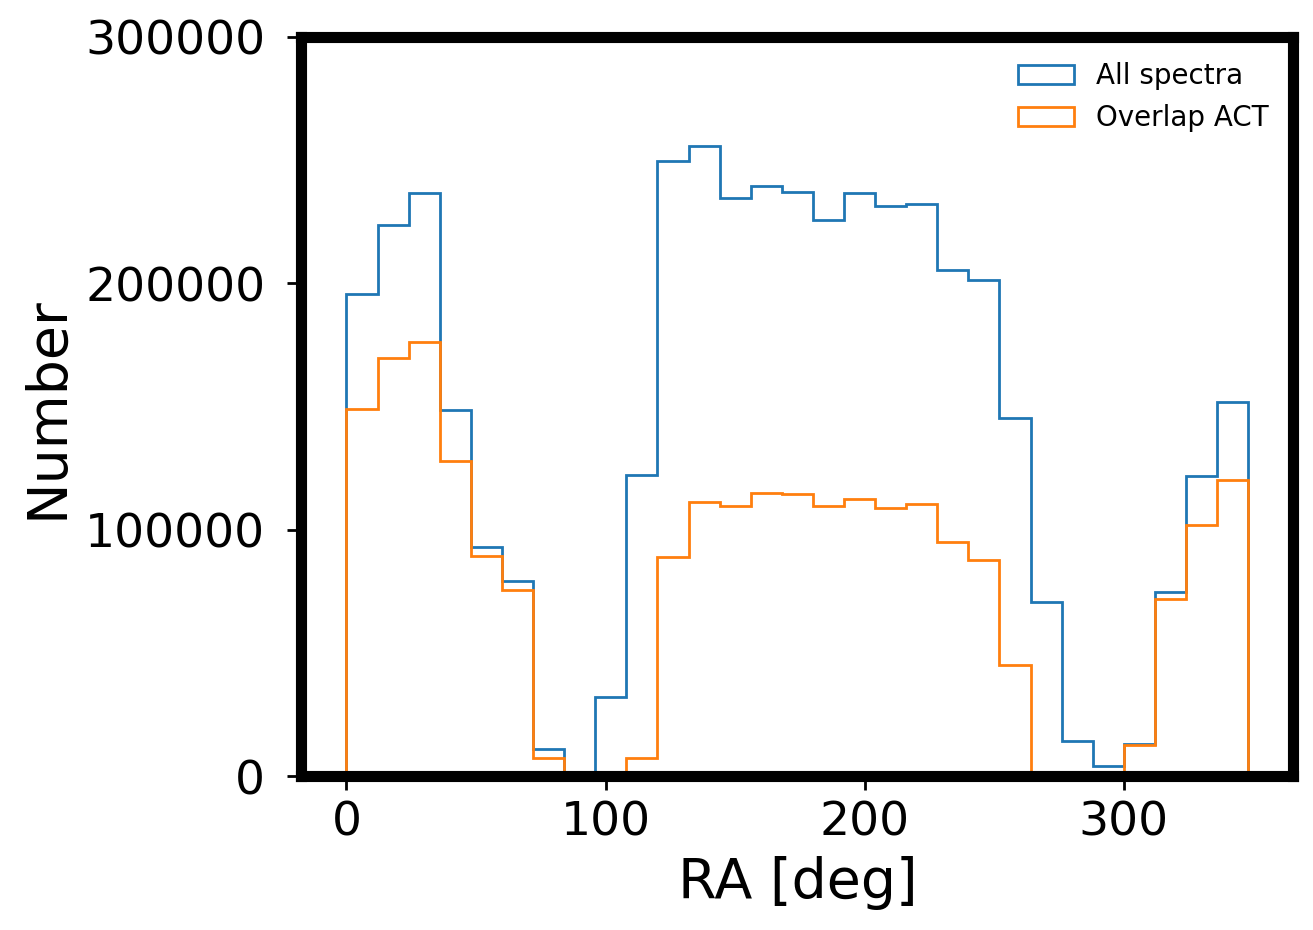

In [21]:
n_bins = np.arange(0, 360, 12)

plt.hist(ra, bins=n_bins, lw=2.0, label=r'All spectra', histtype='step')
plt.hist(ra[overlapFlag==1], bins=n_bins, lw=2.0, label=r'Overlap ACT', histtype='step')

plt.xlabel(r'RA [deg]', fontsize=20)
plt.ylabel('Number', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.ylim(0, 300000)
plt.legend(fontsize=10)
plt.show()


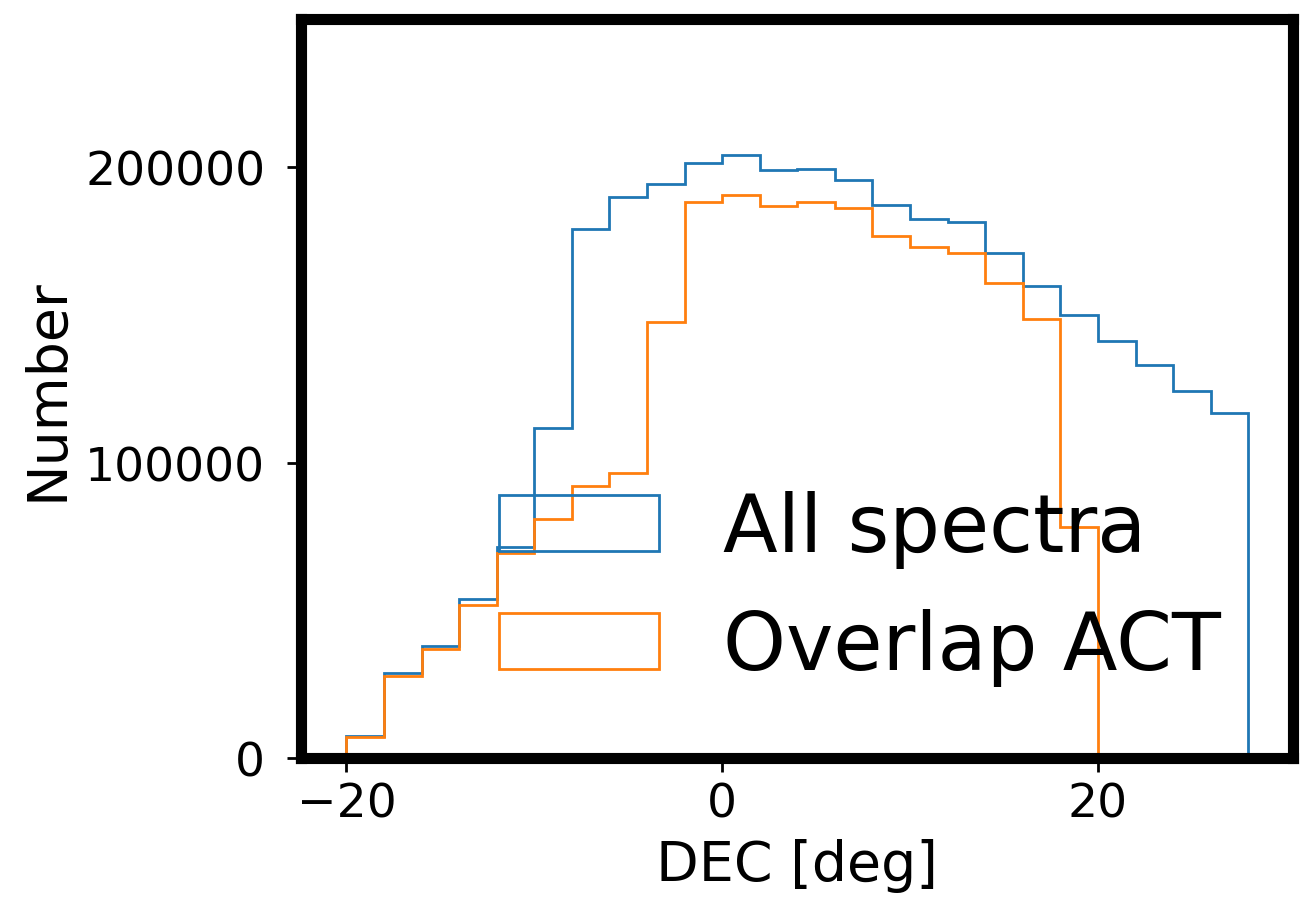

In [22]:
n_bins = np.arange(-20, 30, 2)

plt.hist(dec, bins=n_bins, lw=2.0, label=r'All spectra', histtype='step')
plt.hist(dec[overlapFlag==1], bins=n_bins, lw=2.0, label=r'Overlap ACT', histtype='step')

plt.xlabel(r'DEC [deg]', fontsize=20)
plt.ylabel('Number', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.ylim(0, 250000)
plt.legend()
plt.show()


In [35]:
a=np.loadtxt("/home/jiaqu/Thumbstack_DESI/output/catalogue//full_catalog_Y3.txt")

In [36]:
b=np.loadtxt('/home/jiaqu/Thumbstack_DESI/output/catalogue/full_catalog_Y3_renorm.txt')

In [38]:
are_equal = np.array_equal(a, b)
print(f"Arrays are equal: {are_equal}")

Arrays are equal: True


In [23]:
pre_rec_sort_ACT = pre_rec_sort[overlapFlag == 1]

print("Total galaxies: "+str(len(pre_rec_sort_ACT)))

Total galaxies: 2457983


In [27]:
ra = np.array(pre_rec_NGC_sort["RA"])
dec = np.array(pre_rec_NGC_sort["DEC"])
nObj = len(ra)
hit = sky2map(ra, dec, cmbMask_2)
thresh=0.95

overlapFlag_n = np.array(hit>thresh)*1

pre_rec_NGC_sort_ACT = pre_rec_NGC_sort[overlapFlag_n == 1]
print("Total galaxies: "+str(len(pre_rec_NGC_sort_ACT)))

Total galaxies: 1216845


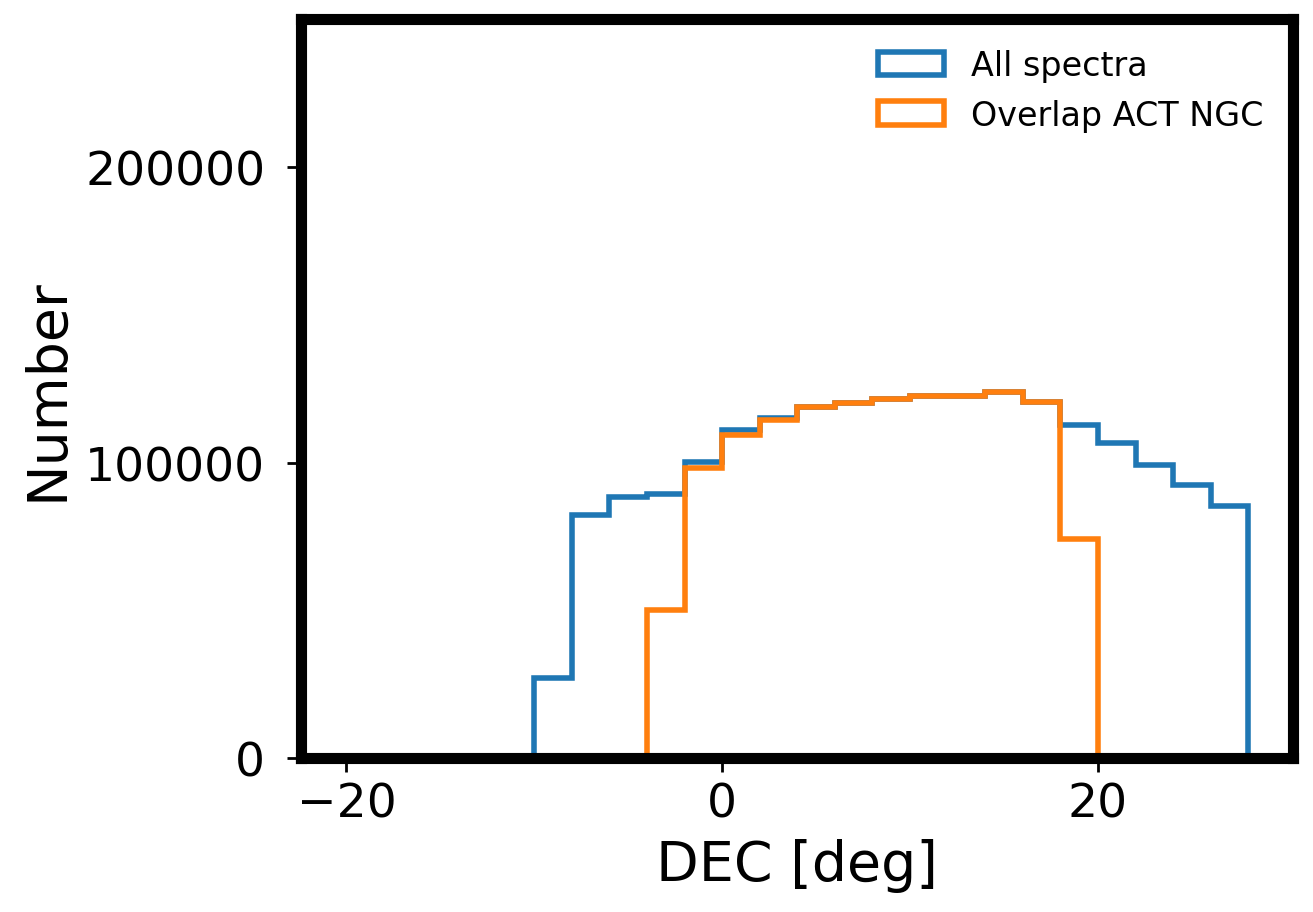

In [62]:
n_bins = np.arange(-20, 30, 2)

plt.hist(dec, bins=n_bins, lw=2.0, label=r'All spectra', histtype='step')
plt.hist(dec[overlapFlag_n==1], bins=n_bins, lw=2.0, label=r'Overlap ACT NGC', histtype='step')

plt.xlabel(r'DEC [deg]', fontsize=20)
plt.ylabel('Number', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.ylim(0, 250000)
plt.legend(fontsize=12)
plt.show()


In [28]:
ra = np.array(pre_rec_SGC_sort["RA"])
dec = np.array(pre_rec_SGC_sort["DEC"])
nObj = len(ra)
hit = sky2map(ra, dec, cmbMask)
thresh=0.95

overlapFlag_s = np.array(hit>thresh)*1

pre_rec_SGC_sort_ACT = pre_rec_SGC_sort[overlapFlag_s == 1]
print("Total galaxies: "+str(len(pre_rec_SGC_sort_ACT)))

Total galaxies: 1240279


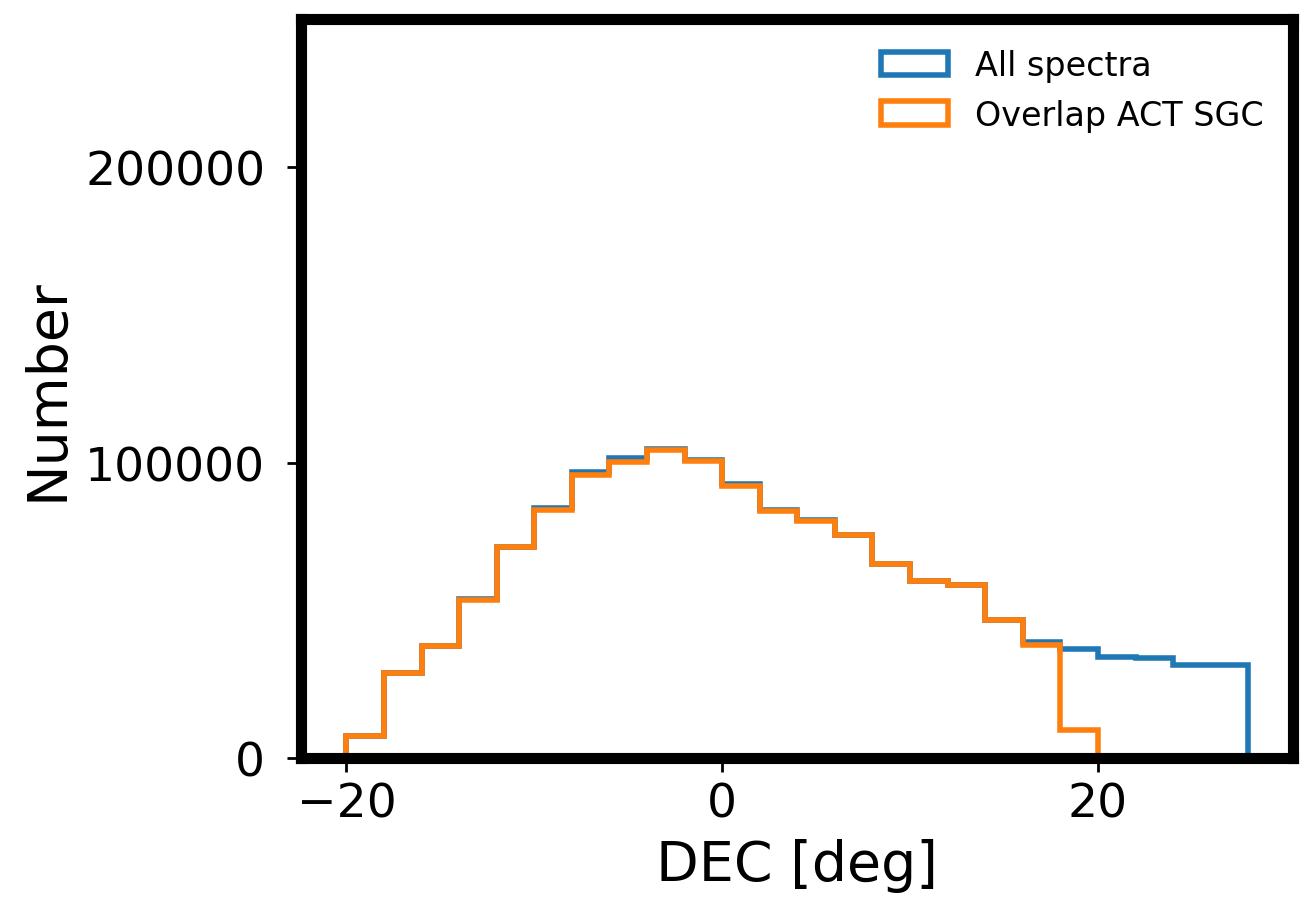

In [59]:
n_bins = np.arange(-20, 30, 2)

plt.hist(dec, bins=n_bins, lw=2.0, label=r'All spectra', histtype='step')
plt.hist(dec[overlapFlag_s==1], bins=n_bins, lw=2.0, label=r'Overlap ACT SGC', histtype='step')

plt.xlabel(r'DEC [deg]', fontsize=20)
plt.ylabel('Number', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.ylim(0, 250000)
plt.legend(fontsize=12)
plt.show()


In [52]:
overlapFlag_n.shape

(2940585,)

In [53]:
dec.shape

(1527898,)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 4468483 but corresponding boolean dimension is 2940585

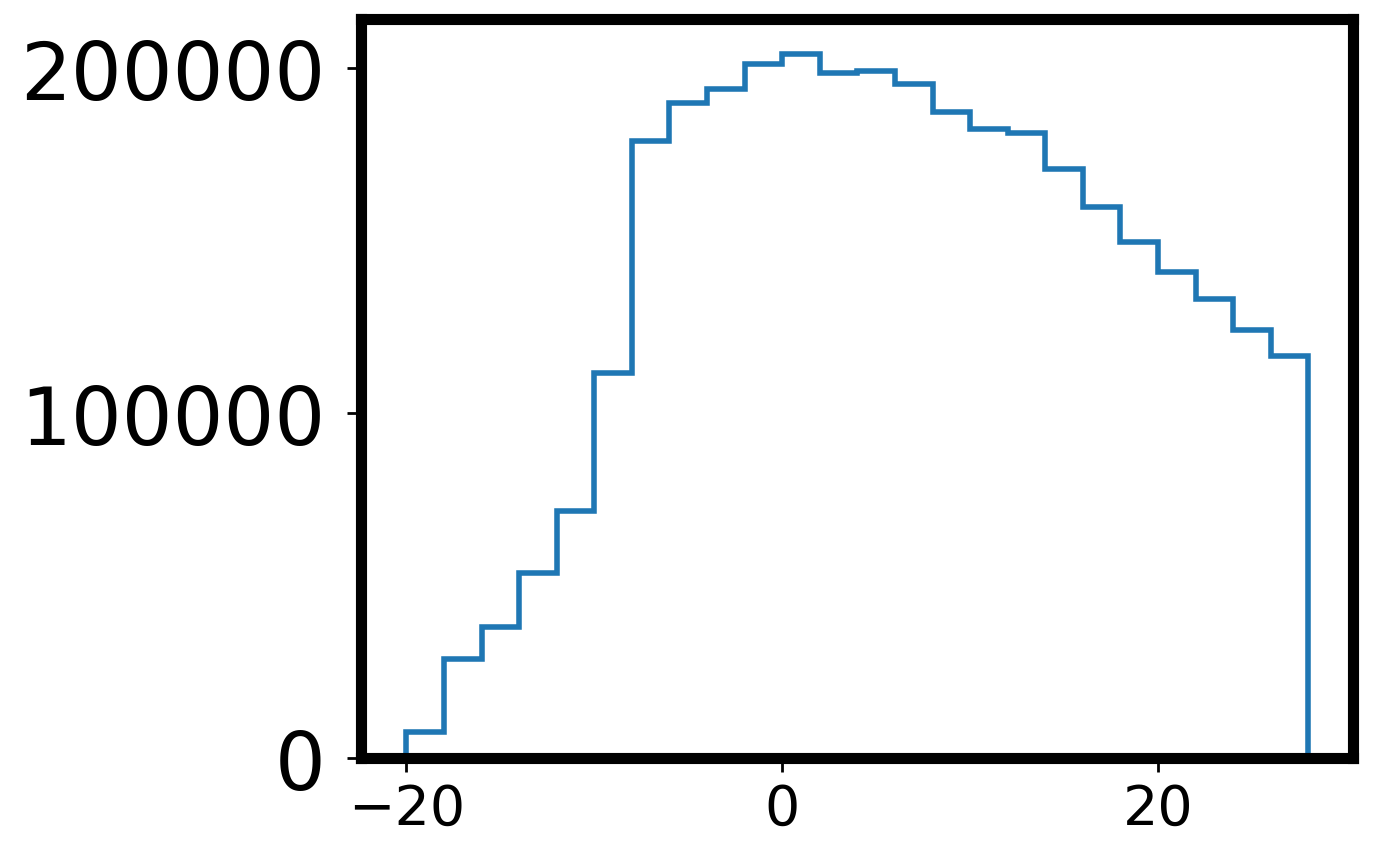

In [57]:
n_bins = np.arange(-20, 30, 2)

plt.hist(dec, bins=n_bins, lw=2.0, label=r'All spectra', histtype='step')
plt.hist(dec[overlapFlag_n==1], bins=n_bins, lw=2.0, label=r'Overlap ACT NGC', histtype='step')
plt.hist(dec[overlapFlag_s==1], bins=n_bins, lw=2.0, label=r'Overlap ACT SGC', histtype='step')

plt.xlabel(r'DEC [deg]', fontsize=20)
plt.ylabel('Number', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.ylim(0, 250000)
plt.legend(fontsize=12)
plt.show()


In [29]:
np.savetxt('/home/jiaqu/Thumbstack_DESI/output/catalogue/NGC_catalog_Y3.txt', np.array(pre_rec_NGC_sort_ACT[["RA", "DEC", "Z", "VEL_LOS"]]))
np.savetxt('/home/jiaqu/Thumbstack_DESI/output/catalogue/SGC_catalog_Y3.txt', np.array(pre_rec_SGC_sort_ACT[["RA", "DEC", "Z", "VEL_LOS"]]))


In [24]:
np.savetxt('/home/jiaqu/Thumbstack_DESI/output/catalogue/full_catalog_Y3.txt', np.array(pre_rec_sort_ACT[["RA", "DEC", "Z", "VEL_LOS"]]))
np.savetxt('/home/jiaqu/Thumbstack_DESI/output/catalogue/full_catalog_Y3_renorm.txt', np.array(pre_rec_sort_ACT[["RA", "DEC", "Z", "VEL_LOS_RENORM"]]))


In [10]:
catalogue=np.loadtxt('/home/jiaqu/Thumbstack_DESI/output/catalogue/full_catalog_Y3_renorm.txt')



In [32]:
catalogue[:,3]

array([-125.19654742,  185.63704618,  -53.07805857, ...,   63.5572726 ,
        162.73968409,   31.18631184])

In [22]:
filtmask=np.loadtxt("/home/jiaqu/Thumbstack_DESI/output/output/y3_final_renorm/diskring_filtmap.txt")
#overlap_flag=np.loadtxt("/home/jiaqu/Thumbstack_DESI/output/output/y3_final_renorm/ov

In [25]:
overlapFlag.shape

(4468483,)

In [24]:
filtmask=filtmask[overlapFlag==1]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 2457983 but corresponding boolean dimension is 4468483

In [20]:
overlapFlag

array([0, 1, 1, ..., 0, 1, 1])

In [19]:
np.savetxt('full_catalog_Y3_sub.txt', np.array(pre_rec_sort_ACT[["RA", "DEC", "Z", "VEL_LOS"]])[:30000])


In [21]:
np.loadtxt('full_catalog_Y3_sub.txt').shape

(30000, 4)

In [69]:
pre_rec_sort_ACT

,TARGETID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,WEIGHT_IMLIN,WEIGHT_SYS,WEIGHT,WEIGHT_COMP,NX,WEIGHT_FKP,GC,DISP_LOS,VEL_LOS,VEL_LOS_RENORM
1157753,39628099867902286,0.400000,5,208.989888,13.072389,b'S',1.000000,1.000000,1.024966,1.024966,0.982506,1.0,0.000495,0.167948,NGC,-2.392859,-103.765963,-125.196547
1077018,39628031408475350,0.400000,4,8.035880,10.169007,b'S',0.982143,1.000000,0.993959,0.993959,0.928972,1.0,0.000501,0.166424,SGC,3.552472,153.860533,185.637046
569197,39627866362614475,0.400000,5,186.252251,3.344247,b'S',1.000000,1.000000,1.026485,1.026485,0.983963,1.0,0.000495,0.167948,NGC,-1.014764,-43.992397,-53.078059
422187,39627804999947076,0.400001,4,128.448024,0.680367,b'S',1.000000,1.000000,0.989646,0.989646,0.922510,1.0,0.000477,0.173244,NGC,2.829268,122.556569,147.867887
1176800,39628106360690132,0.400001,5,246.150677,13.247830,b'S',1.000000,1.000000,0.990374,0.990374,0.949348,1.0,0.000495,0.167948,NGC,3.986765,172.654462,208.312362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440383,39627811689859821,1.099994,5,167.126745,1.037269,b'S',1.000000,1.000590,0.978500,0.978500,0.938519,1.0,0.000063,0.614432,NGC,3.254792,176.004322,152.610369
743526,39627820854412156,1.099994,5,353.275873,1.304790,b'S',1.000000,1.006320,1.003815,1.003815,0.969443,1.0,0.000063,0.614494,SGC,2.867524,155.074454,134.462415
509736,39627706458964389,1.099998,5,14.279909,-3.292290,b'S',1.000000,1.000000,0.999792,0.999792,0.959493,1.0,0.000063,0.614494,SGC,1.355010,73.300246,63.557273
875629,39627898834914361,1.099999,6,324.793717,4.417875,b'S',1.000000,1.005401,1.018689,1.018689,0.998160,1.0,0.000064,0.609411,SGC,3.470976,187.686827,162.739684


In [70]:
df=pre_rec_sort_ACT

In [71]:
df1 = df[(df['Z'] > 0.4) & (df['Z'] <= 0.6)]
df2 = df[(df['Z'] > 0.6) & (df['Z'] <= 0.8)]
df3 = df[(df['Z'] > 0.8) & (df['Z'] <= 0.95)]
df4 = df[(df['Z'] > 0.95) & (df['Z'] <= 1.1)]

In [82]:
df3['Z'].max()

0.9499999285588658

In [83]:
df4['Z'].min()

0.9500000379277422

In [88]:
bins = np.linspace(0.4, 1.1, 80)  # e.g. 35 bins


In [95]:
np.loadtxt("/home/r/rbond/jiaqu/Thumbstack_DESI/z1_catalog_Y3.txt")

IsADirectoryError: [Errno 21] Is a directory: '/home/r/rbond/jiaqu/Thumbstack_DESI/z1_catalog_Y3.txt'

In [99]:
np.savetxt('/home/r/rbond/jiaqu/sims/DESI/catalogue/z1_catalog_Y3.txt', np.array(df1[["RA", "DEC", "Z", "VEL_LOS"]]))


In [1]:
plt.figure(figsize=(8,5))

# Plot each subset with a step histogram
plt.hist(df1['Z'], bins=bins, histtype='step', color='blue', 
         linewidth=2, label='z1')
plt.hist(df2['Z'], bins=bins, histtype='step', color='dodgerblue', 
         linewidth=2, label='z2')
plt.hist(df3['Z'], bins=bins, histtype='step', color='green', 
         linewidth=2, label='z3')
plt.hist(df4['Z'], bins=bins, histtype='step', color='limegreen', 
         linewidth=2, label='z4')

# Label axes, add legend, etc.
plt.xlabel('z')
plt.ylabel('Number')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

## 4. Extra: Save files for VisIt

In [17]:
# # Save to vtk for VisIt
# nObj = len(pre_rec_NGC)

# # pathVisIt = '/global/homes/.../NGC.vtk'

# # create vtk file
# f = open(pathVisIt,'w')
# f.write('# vtk DataFile Version 3.0\n')
# f.write('Catalog data for visualization\n')
# f.write('ASCII\n')
# f.write('\n')

# Position = utils.sky_to_cartesian(np.array(pre_rec_NGC['chi_pre']), pre_rec_NGC['RA'], pre_rec_NGC['DEC'])

# coordX = Position[:, 0] 
# coordY = Position[:, 1] 
# coordZ = Position[:, 2] 

# # Cartesian coord
# f.write('DATASET POLYDATA\n')
# f.write('POINTS '+str(nObj)+' DOUBLE\n')
# for iobj in range(nObj):
#     f.write(format(coordX[iobj], '.10e')+' '+format(coordY[iobj], '.10e')+' '+format(coordZ[iobj], '.10e')+'\n')
# f.write('\n')
# f.write('POINT_DATA '+str(nObj)+'\n')

# # True velocity: line of sight
# f.write('SCALARS Vel_LOS DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# for iobj in range(nObj):
#     f.write(format(vel_NGC_LOS[iobj], '.10e')+'\n')
# f.write('\n')

# # True velocity: across line of sight
# f.write('SCALARS Vel_ACROSS DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# for iobj in range(nObj):
#     f.write(format(vel_NGC_ACROSS[iobj], '.10e')+'\n')
# f.write('\n')

# # Redshift
# f.write('SCALARS Photometric_Redshift DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# Z = np.array(pre_rec_NGC['Z'])
# for iobj in range(nObj):
#     f.write(format(Z[iobj], '.10e')+'\n')
# f.write('\n')

# # RA
# f.write('SCALARS RA DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# RA = np.array(pre_rec_NGC['RA'])
# for iobj in range(nObj):
#     f.write(format(RA[iobj], '.10e')+'\n')
# f.write('\n')


# # DEC
# f.write('SCALARS DEC DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# DEC = np.array(pre_rec_NGC['DEC'])
# for iobj in range(nObj):
#     f.write(format(DEC[iobj], '.10e')+'\n')
# f.write('\n')

# f.close()


In [18]:
# # Save to vtk for VisIt
# nObj = len(pre_rec_SGC)

# # pathVisIt = '/global/homes/.../SGC.vtk'

# # create vtk file
# f = open(pathVisIt,'w')
# f.write('# vtk DataFile Version 3.0\n')
# f.write('Catalog data for visualization\n')
# f.write('ASCII\n')
# f.write('\n')

# Position = utils.sky_to_cartesian(np.array(pre_rec_SGC["chi_pre"]), pre_rec_SGC['RA'], pre_rec_SGC['DEC'])

# coordX = Position[:, 0] 
# coordY = Position[:, 1] 
# coordZ = Position[:, 2] 

# # Cartesian coord
# f.write('DATASET POLYDATA\n')
# f.write('POINTS '+str(nObj)+' DOUBLE\n')
# for iobj in range(nObj):
#     f.write(format(coordX[iobj], '.10e')+' '+format(coordY[iobj], '.10e')+' '+format(coordZ[iobj], '.10e')+'\n')
# f.write('\n')

# f.write('POINT_DATA '+str(nObj)+'\n')

# # True velocity: line of sight
# f.write('SCALARS Vel_LOS DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# for iobj in range(nObj):
#     f.write(format(vel_SGC_LOS[iobj], '.10e')+'\n')
# f.write('\n')

# # True velocity: across line of sight
# f.write('SCALARS Vel_ACROSS DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# for iobj in range(nObj):
#     f.write(format(vel_SGC_ACROSS[iobj], '.10e')+'\n')
# f.write('\n')

# # Redshift
# f.write('SCALARS Photometric_Redshift DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# Z = np.array(pre_rec_SGC['Z'])
# for iobj in range(nObj):
#     f.write(format(Z[iobj], '.10e')+'\n')
# f.write('\n')

# # RA
# f.write('SCALARS RA DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# RA = np.array(pre_rec_SGC['RA'])
# for iobj in range(nObj):
#     f.write(format(RA[iobj], '.10e')+'\n')
# f.write('\n')


# # DEC
# f.write('SCALARS DEC DOUBLE\n')
# f.write('LOOKUP_TABLE default\n')
# DEC = np.array(pre_rec_SGC['DEC'])
# for iobj in range(nObj):
#     f.write(format(DEC[iobj], '.10e')+'\n')
# f.write('\n')

# f.close()


In [1]:
import pandas as pd

In [2]:
galcat = pd.read_csv("/scratch/jiaqu/desi/output/test_new/filtered_catalog.csv")


In [3]:
galcat.RA

0      231.789832
1      124.640541
2      179.399494
3      246.150677
4      178.330193
          ...    
654    255.353373
655    249.952619
656    190.670398
657    323.546237
658     54.860177
Name: RA, Length: 659, dtype: float64

In [27]:
pd.read_csv("/scratch/jiaqu/desi/output/test_new/filtered_catalog.csv")

,RA,DEC,Z,vR,Mstellar,object_index,filter_passed
0,231.789832,1.575652,0.400001,-134.204338,0.0,0,True
1,124.640541,11.304746,0.400002,-59.453933,0.0,1,True
2,179.399494,6.043975,0.400002,-320.079401,0.0,2,True
3,246.150677,13.247830,0.400003,123.173936,0.0,3,True
4,178.330193,2.521484,0.400004,-107.334451,0.0,4,True
...,...,...,...,...,...,...,...
654,255.353373,6.131462,0.400841,-434.901746,0.0,994,True
655,249.952619,5.669085,0.400842,-132.038510,0.0,996,True
656,190.670398,2.103567,0.400843,-93.579425,0.0,997,True
657,323.546237,1.681252,0.400843,-194.597486,0.0,998,True
